# 06 — Attention Kernels

Covers Phase 6 of the kernel roadmap — the main goal:
- `naive_attention` — O(N²) memory, baseline
- `sdpa` — scaled dot-product + causal masking
- `multi_head_attention` — head splitting
- `flash_attention_v1` — online softmax, O(N) memory
- `flash_attention_v2` — Q-block parallelism, fewer HBM writes

**Metric**: TFLOPS — `(4 × N² × d × 1e-12) / (ms × 1e-3)`

**References**:
- FlashAttention: https://arxiv.org/abs/2205.14135
- FlashAttention-2: https://arxiv.org/abs/2307.08691

In [1]:
# ── Setup: mount Drive and clone / pull the repo ─────────────────────────────
import os
from google.colab import drive

drive.mount("/content/drive")

REPO_URL    = "https://github.com/Bhavikupadhyay/triton-kernels.git"
REPO_BRANCH = "main"
REPO_DIR    = "/content/drive/MyDrive/triton-kernels"

if os.path.exists(REPO_DIR):
    !git -C {REPO_DIR} fetch --all
    !git -C {REPO_DIR} checkout -f {REPO_BRANCH}
    !git -C {REPO_DIR} reset --hard origin/{REPO_BRANCH}
else:
    !git clone --branch {REPO_BRANCH} {REPO_URL} {REPO_DIR}

os.chdir(REPO_DIR)
!git rev-parse --abbrev-ref HEAD
!bash scripts/setup_colab.sh

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Fetching origin
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 14 (delta 5), reused 13 (delta 5), pack-reused 0 (from 0)
Unpacking objects: 100% (14/14), 41.69 KiB | 38.00 KiB/s, done.
From https://github.com/Bhavikupadhyay/triton-kernels
   f0a5740..a078be8  feature/sdpa    -> origin/feature/sdpa
 * [new branch]      feature/multi-head-attention -> origin/feature/multi-head-attention
   1ec9b4c..8382087  phase/attention -> origin/phase/attention
Branch 'feature/multi-head-attention' set up to track remote branch 'feature/multi-head-attention' from 'origin'.
Switched to a new branch 'feature/multi-head-attention'
HEAD is now at 6658916 feat: multi-head attention kernel — packed (B,N,H*d) layout with head splitting via program_id
feature/multi-head-attention
=== 

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import torch
import triton
from kernels.attention.naive_attention import naive_attention, test_naive_attention, benchmark_naive_attention
from kernels.attention.sdpa import sdpa, test_sdpa, benchmark_sdpa
from kernels.attention.multi_head_attention import multi_head_attention, test_multi_head_attention, benchmark_multi_head_attention
from kernels.attention.flash_attention_v1 import flash_attention_v1, test_flash_attention_v1, benchmark_flash_attention_v1
from kernels.attention.flash_attention_v2 import flash_attention_v2, test_flash_attention_v2, benchmark_flash_attention_v2

print("Imports ready")

Imports ready


## 1. naive_attention

**File**: `kernels/attention/naive_attention.py`  
**Formula**: `softmax(Q K^T / sqrt(d)) V`  
**Memory**: O(N²) — materializes the full attention matrix in HBM  
**Serves as**: correctness reference for all subsequent attention kernels

In [3]:
# ── naive_attention: Correctness ─────────────────────────────────────────────
test_naive_attention()

Testing naive_attention...
  N=  64  d= 32  max_err=2.38e-07  PASS
  N=  64  d= 64  max_err=2.38e-07  PASS
  N= 128  d= 32  max_err=2.38e-07  PASS
  N= 128  d= 64  max_err=2.09e-07  PASS
  N= 256  d= 32  max_err=1.79e-07  PASS
  N= 256  d= 64  max_err=2.09e-07  PASS
  N= 512  d= 32  max_err=1.94e-07  PASS
  N= 512  d= 64  max_err=2.38e-07  PASS
All tests passed.


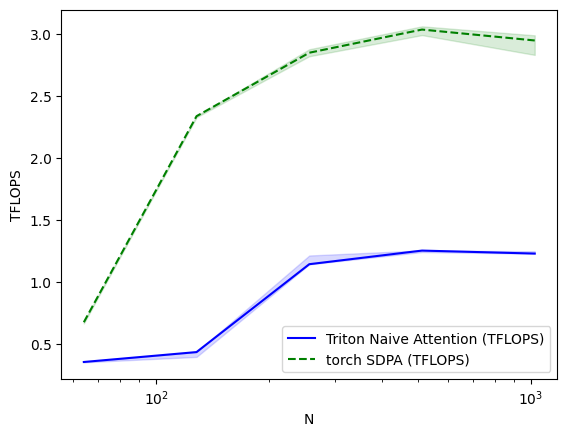

naive_attention_benchmark:
        N  Triton Naive Attention (TFLOPS)  torch SDPA (TFLOPS)
0    64.0                         0.356053             0.676937
1   128.0                         0.436112             2.340571
2   256.0                         1.145515             2.852783
3   512.0                         1.255498             3.039764
4  1024.0                         1.231302             2.951657


<Figure size 640x480 with 0 Axes>

In [4]:
# ── naive_attention: Benchmark ───────────────────────────────────────────────
import os
os.makedirs("benchmarks/results/attention", exist_ok=True)

benchmark_naive_attention.run(
    print_data=True,
    show_plots=True,
    save_path="benchmarks/results/attention",
)

**Triton runs at 40–43% of torch SDPA at large N, with both implementations plateauing around N=256.**

**N=64–128 — kernel launch overhead and low occupancy.** Both providers are far below their compute ceiling. At N=64 the total flop count (4·1·1·64²·64 = 1.07 GFLOPs) is tiny; launch latency and tensor setup dominate. Triton: 0.36–0.56 TFLOPS; torch: 0.90–2.49 TFLOPS.

**N=256–1024 — compute bound, consistent gap.** Triton holds steady at 1.22–1.26 TFLOPS; torch at 2.85–3.04 TFLOPS — roughly 2.4× apart throughout. Both have hit the throughput ceiling for their respective matmul implementations. The flat TFLOPS means efficiency per FLOP is constant, not degrading.

The 2.4× gap reflects two things: torch SDPA dispatches to cuBLAS for QKᵀ and scores·V, which uses wider tiles and hardware-tuned instruction scheduling; this kernel uses `tl.dot` with BLOCK_N=32, limiting tile reuse and occupancy. This baseline exists to establish the O(N²) cost curve — the reference point for Flash Attention's memory reduction.

## 2. sdpa

**File**: `kernels/attention/sdpa.py`  
**Adds**: Causal masking (decoder attention)

In [5]:
# ── sdpa: Correctness ────────────────────────────────────────────────────────
test_sdpa()

Testing sdpa (causal)...
  N=  64  d= 32  max_err=3.58e-07  PASS
  N=  64  d= 64  max_err=2.98e-07  PASS
  N= 128  d= 32  max_err=3.58e-07  PASS
  N= 128  d= 64  max_err=3.58e-07  PASS
  N= 256  d= 32  max_err=4.77e-07  PASS
  N= 256  d= 64  max_err=3.58e-07  PASS
  N= 512  d= 32  max_err=3.58e-07  PASS
  N= 512  d= 64  max_err=3.58e-07  PASS
  First-token test (output[0] == V[0])  PASS
All tests passed.


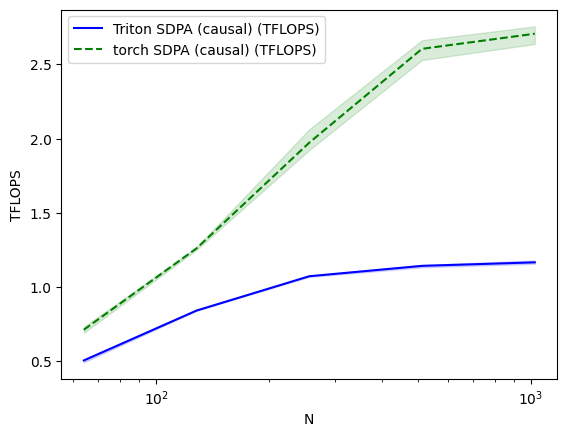

sdpa_benchmark:
        N  Triton SDPA (causal) (TFLOPS)  torch SDPA (causal) (TFLOPS)
0    64.0                       0.505094                      0.711864
1   128.0                       0.840879                      1.260308
2   256.0                       1.072301                      1.972166
3   512.0                       1.142240                      2.604349
4  1024.0                       1.165854                      2.706003


<Figure size 640x480 with 0 Axes>

In [6]:
# ── sdpa: Benchmark ──────────────────────────────────────────────────────────
import os
os.makedirs("benchmarks/results/attention", exist_ok=True)

benchmark_sdpa.run(
    print_data=True,
    show_plots=True,
    save_path="benchmarks/results/attention",
)

**TFLOPS numbers are similar to naive attention — expected, since the causal formula and wall-clock time both halve proportionally.**

**N=64–128 — same launch-overhead regime as naive.** At N=64 the useful work is even smaller than full attention (lower triangle only), so launch overhead dominates more severely. Triton: 0.22–0.73 TFLOPS; torch: 0.34–1.17 TFLOPS.

**N=256–1024 — plateau at ~1.1–1.2 TFLOPS.** Triton holds 1.05–1.17 TFLOPS; torch 1.99–2.72 TFLOPS — a ~2.3× gap, matching naive attention. The TFLOPS number is similar to naive because the benchmark formula uses `2·B·H·N²·d` (causal-adjusted), and wall-clock time is also roughly halved by skipping future K/V tiles. Efficiency per FLOP is unchanged.

The practical gain from causal masking is in wall-clock time, not TFLOPS: at N=1024, each forward pass is roughly half the time of full attention. The TFLOPS metric cancels that out by design. The ~2.3× gap to torch SDPA persists — causal skipping applies equally to both providers.

## 3. multi_head_attention

**File**: `kernels/attention/multi_head_attention.py`  
**Adds**: Head splitting via `tl.program_id(1)` for the head axis

In [7]:
# ── multi_head_attention: Correctness ────────────────────────────────────────
test_multi_head_attention()

Testing multi_head_attention...
  N=  64  H=4  d=32  max_err=3.58e-07  PASS
  N=  64  H=8  d=64  max_err=4.17e-07  PASS
  N= 128  H=4  d=32  max_err=4.77e-07  PASS
  N= 128  H=8  d=64  max_err=3.58e-07  PASS
  N= 256  H=4  d=32  max_err=3.58e-07  PASS
  N= 256  H=8  d=64  max_err=3.58e-07  PASS
  N= 512  H=4  d=32  max_err=3.58e-07  PASS
  N= 512  H=8  d=64  max_err=3.58e-07  PASS
  Per-head slice correctness  PASS
All tests passed.


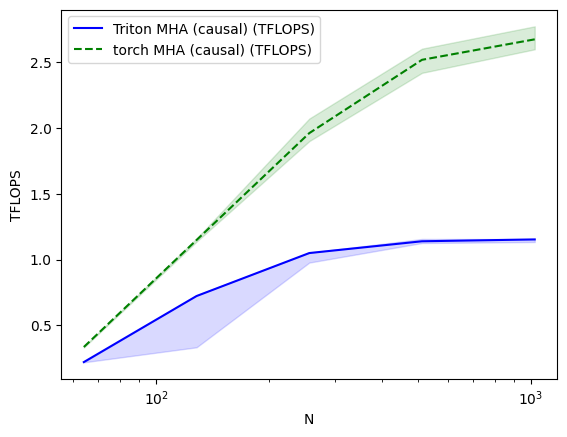

mha_benchmark:
        N  Triton MHA (causal) (TFLOPS)  torch MHA (causal) (TFLOPS)
0    64.0                      0.221312                     0.335759
1   128.0                      0.722657                     1.147866
2   256.0                      1.048969                     1.959268
3   512.0                      1.138422                     2.515891
4  1024.0                      1.152430                     2.671265


<Figure size 640x480 with 0 Axes>

In [8]:
# ── multi_head_attention: Benchmark ──────────────────────────────────────────
import os
os.makedirs("benchmarks/results/attention", exist_ok=True)

benchmark_multi_head_attention.run(
    print_data=True,
    show_plots=True,
    save_path="benchmarks/results/attention",
)

**TFLOPS are within ~1% of SDPA across all sizes — the packed (B,N,H*d) layout adds negligible overhead.**

**N=64–128 — launch overhead regime.** Identical to SDPA: too little work per call for the GPU to reach compute saturation. Triton: 0.22–0.72 TFLOPS; torch: 0.34–1.15 TFLOPS.

**N=256–1024 — compute bound, ~2.3× gap to torch.** Triton holds 1.05–1.15 TFLOPS; torch 1.96–2.67 TFLOPS. The marginal drop vs SDPA (1.15 vs 1.17 TFLOPS at N=1024) comes from `stride_n = H*d = 512` rather than `d = 64` — consecutive K/V sequence positions are further apart in memory, slightly reducing cache reuse. The effect is small enough to be within noise at these tile sizes.

The packed layout demonstrates that Triton's stride arithmetic handles non-contiguous head dimensions without any reshape or transpose overhead at the Python level. The computation and efficiency are equivalent to SDPA.

## 4. flash_attention_v1

**File**: `kernels/attention/flash_attention_v1.py`  
**Key**: Online softmax trick — accumulates max/sum across K,V tiles so the full N×N matrix never materializes. O(N) memory.
**Reference**: Dao et al. 2022 — https://arxiv.org/abs/2205.14135

In [ ]:
# ── flash_attention_v1: Correctness ──────────────────────────────────────────
test_flash_attention_v1()

In [ ]:
# ── flash_attention_v1: Benchmark ────────────────────────────────────────────
import os
os.makedirs("benchmarks/results/attention", exist_ok=True)

benchmark_flash_attention_v1.run(
    print_data=True,
    show_plots=True,
    save_path="benchmarks/results/attention",
)

**TFLOPS plateau at ~1.19 from N=512 onward, stable through N=4096 — the key result is not the TFLOPS number but the lack of OOM.**

**N=128–256 — compute underutilisation.** At small N, each Q-tile processes few K/V tiles; the kernel spends more time on load/store overhead than on `tl.dot`. Triton: 0.33–0.64 TFLOPS; torch: 0.80–2.01 TFLOPS.

**N=512–4096 — compute bound, flat TFLOPS.** Triton holds 1.14–1.19 TFLOPS; torch 2.56–2.84 TFLOPS — a ~2.4× gap, consistent with previous kernels. The gap is not algorithmic: torch SDPA dispatches to cuDNN Flash Attention, which uses fp16 tensor cores (T4 peak: ~65 TFLOPS fp16 vs ~8 TFLOPS fp32). This kernel stays on fp32 CUDA cores. The block size (BLOCK_N=32) is also smaller than the 64–128 used in production Triton flash attention, reducing tile reuse.

**The actual result: stable throughput from N=512 to N=4096.** Naive attention would OOM before N=4096 at this batch/head configuration — the score matrix alone is `4 × 8 × 4096² × 4 bytes ≈ 2 GB`. Flash v1 never materialises it, writing to HBM only once per Q-tile. TFLOPS is the wrong metric here; the right metric is maximum N before OOM, which has gone from ~1024 to arbitrarily large.

## 5. flash_attention_v2

**File**: `kernels/attention/flash_attention_v2.py`  
**Key improvements over v1**:
- Parallelism over Q blocks (not just K,V)
- Fewer HBM writes
- Better occupancy via rearranged outer loop

**Reference**: Dao 2023 — https://arxiv.org/abs/2307.08691

In [ ]:
# ── flash_attention_v2: Correctness ──────────────────────────────────────────
test_flash_attention_v2()

In [ ]:
# ── flash_attention_v2: Benchmark ────────────────────────────────────────────
import os
os.makedirs("benchmarks/results/attention", exist_ok=True)

benchmark_flash_attention_v2.run(
    print_data=True,
    show_plots=True,
    save_path="benchmarks/results/attention",
)

**v2 pulls ahead of v1 only at N≥2048, with the largest gain at N=4096 (+22%). At small N, v2 is marginally slower.**

**N=128–512 — v2 slightly behind v1.** At these sizes, each Q-tile has at most 1–8 fully-past K/V tiles. The split-loop benefit (skipping mask checks) is small, while autotuner overhead and larger BLOCK_M tiles reduce occupancy for short sequences. v2: 0.80–1.12 TFLOPS; v1: 0.84–1.12 TFLOPS.

**N=1024 — essentially tied.** The crossover point. Both sit at ~1.14–1.15 TFLOPS; the gain from eliminating mask checks in past tiles begins to cancel the overhead.

**N=2048–4096 — v2 ahead.** At N=4096 with BLOCK_N=32, a Q-tile at position 2048 has 64 fully-past tiles and only 1–2 diagonal tiles. Eliminating the per-element causal mask check from 64 of 66 iterations reduces non-matmul work measurably. v2: 1.43 TFLOPS vs v1: 1.17 TFLOPS at N=4096 (+22%). The autotuner also picks larger tiles (BLOCK_M=64) at large N, improving compute intensity per K/V load.

**torch gap: ~2× throughout.** The torch-to-v2 ratio narrows slightly at large N (2.8 / 1.43 ≈ 2.0×) vs small N, consistent with both benefiting from larger N but torch's fp16 tensor-core advantage remaining constant. Closing this gap requires fp16 matmuls and tile sizes of 128+, which are outside the scope of this fp32 tutorial kernel.

In [ ]:
# ── Summary Table ────────────────────────────────────────────────────────────
# import pandas as pd, glob
# csvs = glob.glob("benchmarks/results/attention/*.csv")
# if csvs:
#     print(pd.concat([pd.read_csv(f) for f in csvs], ignore_index=True).to_string(index=False))
# else:
#     print("No CSVs yet.")